   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76             78             75  
Linear Regression: MAE = 10.49, RMSE = 13.40, R² Score = 0.16
Lasso: MAE = 10.63, RMSE = 13.53, R² Score = 0.15
Ridge: MAE = 10.49, RMSE = 13.40, R² Score = 0.

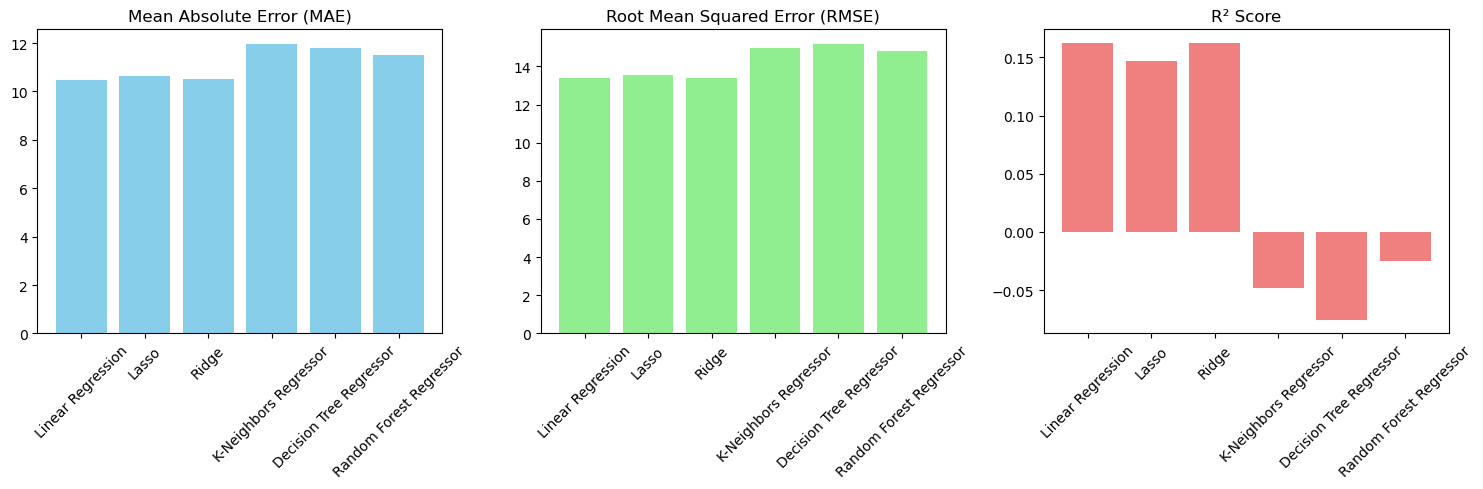

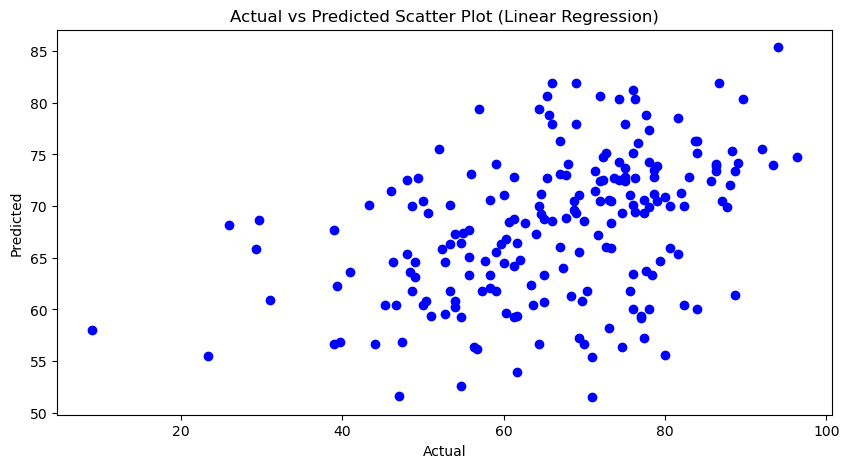

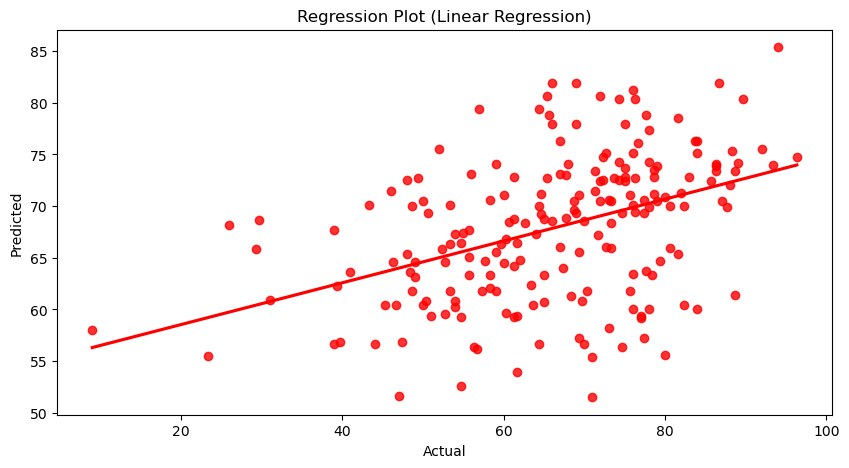

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import Lasso, Ridge, LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load dataset
df = pd.read_csv('student_data.csv')

# Inspect dataset
print(df.head())

# 'Performance' as the average of math, reading, and writing scores
df['Performance'] = df[['math score', 'reading score', 'writing score']].mean(axis=1)


X = df.drop(columns=['math score', 'reading score', 'writing score', 'Performance'])
y = df['Performance']


cat_cols = X.select_dtypes(include=['object']).columns
num_cols = X.select_dtypes(include=['int64', 'float64']).columns

preprocessor = ColumnTransformer([
    ("OneHotEncoder", OneHotEncoder(handle_unknown='ignore'), cat_cols),
    ("StandardScaler", StandardScaler(), num_cols)
])


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

# Define models
models = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(alpha=0.1),
    "Ridge": Ridge(alpha=1),
    "K-Neighbors Regressor": KNeighborsRegressor(n_neighbors=5),
    "Decision Tree Regressor": DecisionTreeRegressor(random_state=42),
    "Random Forest Regressor": RandomForestRegressor(n_estimators=100, random_state=42)
}

# Train evaluate each model
results = {}

for name, model in models.items():
    model.fit(X_train_transformed, y_train)
    y_pred = model.predict(X_test_transformed)

    # Calculate evaluation metrics
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results[name] = {"MAE": mae, "RMSE": rmse, "R² Score": r2}
    print(f"{name}: MAE = {mae:.2f}, RMSE = {rmse:.2f}, R² Score = {r2:.2f}")

# Visualizing performance
model_names = list(results.keys())
mae_scores = [results[m]["MAE"] for m in model_names]
rmse_scores = [results[m]["RMSE"] for m in model_names]
r2_scores = [results[m]["R² Score"] for m in model_names]

plt.figure(figsize=(15, 5))

#compare MAE
plt.subplot(1, 3, 1)
plt.bar(model_names, mae_scores, color='skyblue')
plt.title('Mean Absolute Error (MAE)')
plt.xticks(rotation=45)

#compare RMSE
plt.subplot(1, 3, 2)
plt.bar(model_names, rmse_scores, color='lightgreen')
plt.title('Root Mean Squared Error (RMSE)')
plt.xticks(rotation=45)

#Compare R^2Score
plt.subplot(1, 3, 3)
plt.bar(model_names, r2_scores, color='lightcoral')
plt.title('R² Score')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


best_model = max(results, key=lambda m: results[m]["R² Score"])

plt.figure(figsize=(10, 5))
plt.scatter(y_test, models[best_model].predict(X_test_transformed), color="blue")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title(f"Actual vs Predicted Scatter Plot ({best_model})")
plt.show()

# Regression plot using Seaborn
plt.figure(figsize=(10, 5))
sns.regplot(x=y_test, y=models[best_model].predict(X_test_transformed), ci=None, color="red")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title(f"Regression Plot ({best_model})")
plt.show()